In [19]:
%matplotlib inline

import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l



In [21]:
train_data = pd.read_csv('../data/kaggle_house_pred_train.csv')
test_data = pd.read_csv('../data/kaggle_house_pred_test.csv')


In [8]:
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))


In [9]:
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index

all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std()))

all_features[numeric_features] = all_features[numeric_features].fillna(0)


In [10]:
all_features = pd.get_dummies(all_features, dummy_na=True)


In [22]:
n_train = train_data.shape[0]

train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)

train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1, 1),
                            dtype=torch.float32)


In [23]:
loss = nn.MSELoss()
in_features = train_features.shape[1]

def get_net():
    net = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),

        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.2),

        nn.Linear(128, 64),
        nn.ReLU(),
        
        nn.Linear(64, 1)
    )
    
    # Xavier初始化
    for layer in net:
        if isinstance(layer, nn.Linear):
            nn.init.xavier_uniform_(layer.weight)
        
    return net

def log_rmse(net, features, labels):
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds), torch.log(labels)))
    return rmse.item()


In [24]:
def train(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):

    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)

    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()

        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))

    return train_ls, test_ls


In [25]:
def get_k_fold_data(k, i, X, y):
    fold_size = X.shape[0] // k
    X_train, y_train = None, None

    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]

        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], dim=0)
            y_train = torch.cat([y_train, y_part], dim=0)

    return X_train, y_train, X_valid, y_valid


In [26]:
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay, batch_size):
    train_l_sum, valid_l_sum = 0, 0

    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs,
                                   learning_rate, weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]

        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')

        print(f'折{i + 1}，训练log rmse {train_ls[-1]:f}, 验证log rmse {valid_ls[-1]:f}')

    return train_l_sum / k, valid_l_sum / k


折1，训练log rmse 0.137642, 验证log rmse 0.165852
折2，训练log rmse 0.135615, 验证log rmse 0.164002
折3，训练log rmse 0.136791, 验证log rmse 0.159683
折4，训练log rmse 0.136155, 验证log rmse 0.141671
折5，训练log rmse 0.128790, 验证log rmse 0.166890
5-折验证: 平均训练log rmse 0.134999, 平均验证log rmse 0.159620


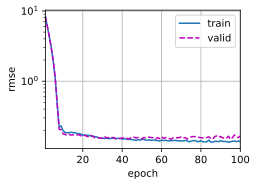

In [30]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 1e-3, 1e-4, 64
train_l, valid_l = k_fold(k, train_features, train_labels,
                          num_epochs, lr, weight_decay, batch_size)

print(f'{k}-折验证: 平均训练log rmse {train_l:f}, 平均验证log rmse {valid_l:f}')


In [31]:
def train_and_pred(train_features, train_labels, test_features, test_labels,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)

    d2l.plot(np.arange(1, num_epochs + 1), [train_ls],
             xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
             legend=['train'], yscale='log')

    print(f'训练log rmse: {train_ls[-1]:f}')

    preds = net(test_features).detach().numpy()
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])

    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)


训练log rmse: 0.135624


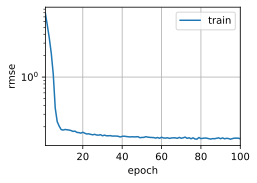

: 

In [ ]:
train_and_pred(train_features, train_labels, test_features, None,
               num_epochs, lr, weight_decay, batch_size)
